In [6]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [7]:
from src.getdata_utils import load_data, split_data

In [8]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


In [9]:
df4=df.copy()
df4.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
import time
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
t0 = time.time()
# ---------------------------
# 1) Use all features except the target
# ---------------------------
assert 'y' in df4.columns, "Expected target column 'y' in df4"
X = df4.drop(columns=['y']).copy()
# Identify numeric vs categorical by dtype (robust)
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]
# ---------------------------
# 2) Preprocessing pipelines
# ---------------------------
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
# OneHotEncoder: force DENSE output across sklearn versions
try:
    cat_ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False)
except TypeError:
    cat_ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse=False)
cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', cat_ohe)
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ],
    remainder='drop'
)
# ---------------------------
# 3) KMeans pipeline
# ---------------------------
kmeans_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=4, n_init=10, random_state=42))
])
print("Fitting KMeans pipeline...")
kmeans_pipe.fit(X)
print("Done.")
# Attach clusters back to df4 (doesn't modify X)
df4['cluster'] = kmeans_pipe.named_steps['clusterer'].labels_
# ---------------------------
# 4) Quick sanity checks / summaries
# ---------------------------
print("\nCluster counts:")
print(df4['cluster'].value_counts().sort_index())
if num_features:
    print("\nNumeric means by cluster:")
    print(df4.groupby('cluster')[num_features].mean().round(2))
if cat_features:
    print("\nTop categorical proportions by cluster (all categorical features):")
    for col in cat_features:   # removed [:5]
        ctab = pd.crosstab(df4['cluster'], df4[col], normalize='index').round(3)
        print(f"\n{col} (row = cluster, values = % within cluster)")
        print(ctab)
print(f"\nElapsed: {time.time() - t0:.2f}s")

Fitting KMeans pipeline...
Done.

Cluster counts:
cluster
0    14552
1    21871
2     7002
3     1786
Name: count, dtype: int64

Numeric means by cluster:
           age  balance    day  duration  campaign   pdays  previous
cluster                                                             
0        52.11  2000.29  15.76    245.66      2.43    4.41      0.10
1        33.95   934.38  15.89    275.01      2.26    0.78      0.04
2        39.65  1435.21  14.00    256.56      2.09  247.97      3.42
3        40.43  1117.74  22.29    160.02     14.26   -0.07      0.02

Top categorical proportions by cluster (all categorical features):

job (row = cluster, values = % within cluster)
job      admin.  blue-collar  entrepreneur  housemaid  management  retired  \
cluster                                                                      
0         0.088        0.201         0.040      0.051       0.199    0.137   
1         0.125        0.225         0.029      0.016       0.211    0.002   
2  

In [11]:
cluster_labels = {
    0: "Older, Established Households",
    1: "Young Working Professionals with Debt Exposure",
    2: "Previously Targeted, Mixed Response Clients",
    3: "Over-Contacted, Low Engagement Group"
}
# Replace numbers with labels
df4['cluster_label'] = df4['cluster'].map(cluster_labels)
# Quick check
print(df4[['cluster', 'cluster_label']].head())

   cluster                                   cluster_label
0        0                   Older, Established Households
1        1  Young Working Professionals with Debt Exposure
2        1  Young Working Professionals with Debt Exposure
3        0                   Older, Established Households
4        1  Young Working Professionals with Debt Exposure


Dynamic label mapping (cluster_id -> label):
  0: Older, Established Households
  1: Young Working Professionals with Debt Exposure
  2: Previously Targeted, Mixed Response Clients
  3: Over-Contacted, Low Engagement Group

Counts by label:
cluster_label
Young Working Professionals with Debt Exposure    21871
Older, Established Households                     14552
Previously Targeted, Mixed Response Clients        7002
Over-Contacted, Low Engagement Group               1786
Name: count, dtype: int64


/tmp/ipykernel_580920/1844885534.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_yes = tmp[tmp['y']=='yes'].groupby('month_cat').size()
/tmp/ipykernel_580920/1844885534.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_no  = tmp[tmp['y']=='no'].groupby('month_cat').size()
/tmp/ipykernel_580920/1844885534.py:267: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_age.boxplot([S['age_in'], S['age_out']],


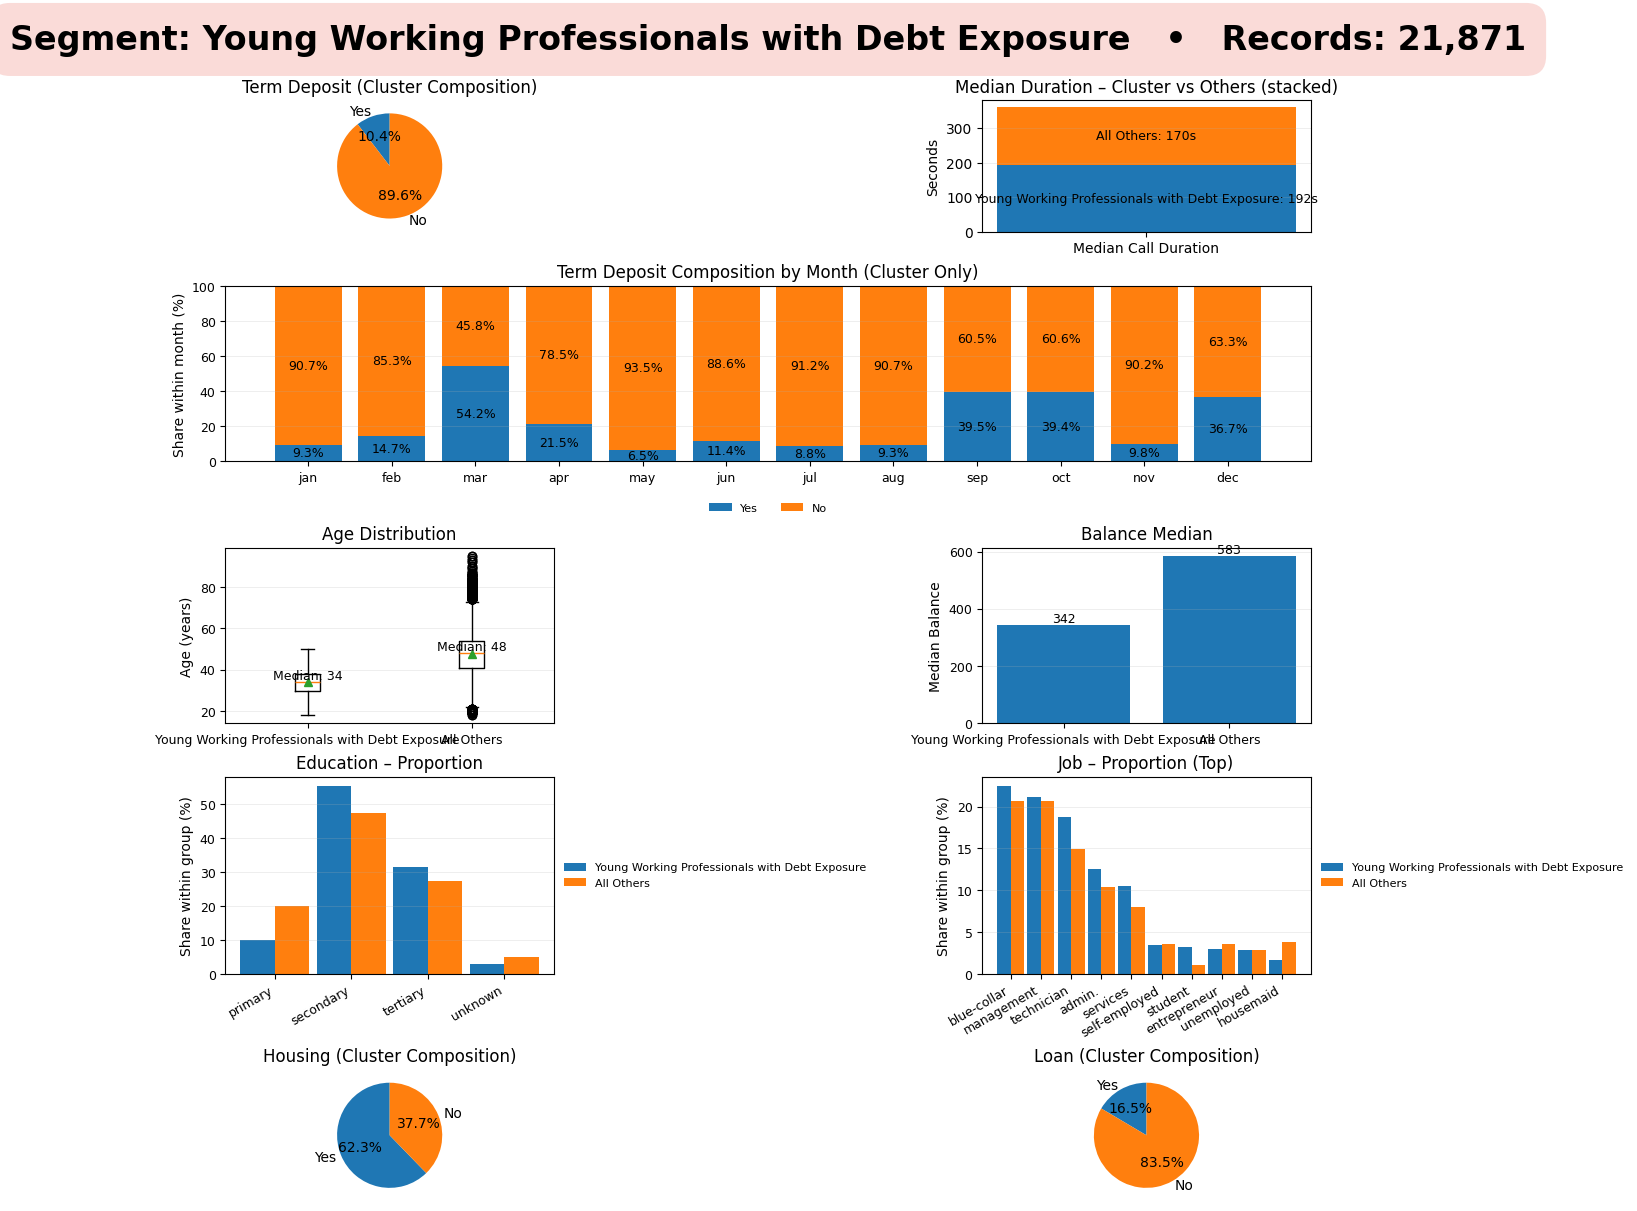

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Optional

# ===================== CONFIG =====================
_MONTH_ORDER = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

# ===================== UTILITIES =====================
def _month_cat(series: pd.Series) -> pd.Categorical:
    s = series.astype(str).str.lower()
    return pd.Categorical(s, categories=_MONTH_ORDER, ordered=True)

def _poutcome_known_rate(s: pd.Series) -> float:
    """Share of poutcome that is not 'unknown'."""
    if len(s) == 0:
        return 0.0
    return 1.0 - (s.astype(str).eq('unknown').mean())

# ===================== DYNAMIC LABELING =====================
def assign_dynamic_cluster_labels(df4: pd.DataFrame) -> dict:
    """
    Assign human labels to numeric cluster IDs based on profile metrics.
      - 'Previously Targeted, Mixed Response Clients' -> highest pdays (tie: most known poutcome)
      - 'Over-Contacted, Low Engagement Group'       -> highest campaign
      - 'Older, Established Households'              -> (remaining) highest age (tie: highest balance)
      - 'Young Working Professionals with Debt Exposure' -> remaining cluster
    """
    g = df4.groupby('cluster', dropna=False)
    stats = pd.DataFrame({
        'n': g.size(),
        'age_mean': g['age'].mean(),
        'balance_mean': g['balance'].mean(),
        'campaign_mean': g['campaign'].mean(),
        'pdays_mean': g['pdays'].mean(),
        'poutcome_known_rate': g['poutcome'].apply(_poutcome_known_rate)
    })

    # 1) Previously targeted
    c_prev = (stats[['pdays_mean','poutcome_known_rate']]
              .sort_values(['pdays_mean','poutcome_known_rate'], ascending=False)
              .index[0])

    # 2) Over-contacted
    remaining = stats.drop(index=c_prev)
    c_over = remaining['campaign_mean'].idxmax()

    # 3) Older, established
    remaining = remaining.drop(index=c_over)
    c_old = (remaining[['age_mean','balance_mean']]
             .sort_values(['age_mean','balance_mean'], ascending=False)
             .index[0])

    # 4) Young working (leftover)
    remaining = remaining.drop(index=c_old)
    c_young = remaining.index[0] if len(remaining) == 1 else stats['age_mean'].idxmin()

    label_map = {
        c_old:   "Older, Established Households",
        c_young: "Young Working Professionals with Debt Exposure",
        c_prev:  "Previously Targeted, Mixed Response Clients",
        c_over:  "Over-Contacted, Low Engagement Group",
    }
    if df4['cluster'].nunique() != len(label_map):
        raise ValueError("Label mapping mismatch with cluster count.")
    return label_map

def ensure_dynamic_labels(df4: pd.DataFrame) -> pd.DataFrame:
    """Attach/refresh df4['cluster_label'] based on the latest cluster assignments."""
    label_map = assign_dynamic_cluster_labels(df4)
    out = df4.copy()
    out['cluster_label'] = out['cluster'].map(label_map)
    return out

def ensure_y_binary(df4: pd.DataFrame) -> pd.DataFrame:
    """Create df4['y_bin'] from 'y' ('yes'/'no')."""
    if 'y_bin' not in df4.columns:
        df4 = df4.copy()
        df4['y_bin'] = df4['y'].map({'yes': 1, 'no': 0})
    return df4

def print_labeling_summary(df4: pd.DataFrame) -> None:
    label_map = assign_dynamic_cluster_labels(df4)
    print("Dynamic label mapping (cluster_id -> label):")
    for cid, lab in label_map.items():
        print(f"  {cid}: {lab}")
    tmp = df4.copy()
    tmp['cluster_label'] = tmp['cluster'].map(label_map)
    print("\nCounts by label:")
    print(tmp['cluster_label'].value_counts())

# ===================== SUMMARIES =====================
def _cluster_id_from_label(df4: pd.DataFrame, label: str) -> int:
    d = (df4[['cluster','cluster_label']]
         .drop_duplicates()
         .set_index('cluster_label')['cluster']
         .to_dict())
    return d[label]

def _summaries_for_cluster(df4: pd.DataFrame, cluster_id: int,
                           job_top_n: int = 10, min_prop: float = 0.01) -> dict:
    lbl = df4.loc[df4['cluster']==cluster_id, 'cluster_label'].iloc[0]
    in_grp  = df4[df4['cluster']==cluster_id].copy()
    out_grp = df4[df4['cluster']!=cluster_id].copy()

    # Age arrays
    age_in  = in_grp['age'].dropna()
    age_out = out_grp['age'].dropna()

    # Balance medians
    bal_med_in  = in_grp['balance'].median()
    bal_med_out = out_grp['balance'].median()

    # Duration medians
    dur_med_in  = in_grp['duration'].median()
    dur_med_out = out_grp['duration'].median()

    # Education proportions
    edu_in  = in_grp['education'].value_counts(normalize=True, dropna=False)
    edu_out = out_grp['education'].value_counts(normalize=True, dropna=False)
    edu_all = sorted(set(edu_in.index).union(edu_out.index), key=lambda x: str(x))
    edu_in, edu_out = edu_in.reindex(edu_all, fill_value=0), edu_out.reindex(edu_all, fill_value=0)
    keep = (edu_in >= min_prop) | (edu_out >= min_prop)
    edu_in, edu_out = edu_in[keep], edu_out[keep]

    # Job proportions (top N by cluster share)
    job_in  = in_grp['job'].value_counts(normalize=True, dropna=False)
    job_out = out_grp['job'].value_counts(normalize=True, dropna=False)
    job_all = sorted(set(job_in.index).union(job_out.index), key=lambda x: str(x))
    job_in, job_out = job_in.reindex(job_all, fill_value=0), job_out.reindex(job_all, fill_value=0)
    if len(job_in) > job_top_n:
        top_jobs = job_in.sort_values(ascending=False).head(job_top_n).index
        job_in, job_out = job_in.loc[top_jobs], job_out.loc[top_jobs]

    # Term deposit composition (counts) – cluster only
    yes_in_cnt  = int(in_grp['y_bin'].sum())
    no_in_cnt   = int(len(in_grp) - yes_in_cnt)

    # Month Yes/No composition (100% stacked) – cluster only
    tmp = in_grp.copy()
    tmp['month_cat'] = _month_cat(tmp['month'])
    month_yes = tmp[tmp['y']=='yes'].groupby('month_cat').size()
    month_no  = tmp[tmp['y']=='no'].groupby('month_cat').size()
    idx = pd.Index(_MONTH_ORDER, dtype='object')  # consistent order
    month_yes = month_yes.reindex(idx, fill_value=0)
    month_no  = month_no.reindex(idx,  fill_value=0)
    month_tot = month_yes + month_no
    with np.errstate(divide='ignore', invalid='ignore'):
        month_yes_pct = (month_yes / month_tot.replace(0, np.nan) * 100).fillna(0)
        month_no_pct  = (month_no  / month_tot.replace(0, np.nan) * 100).fillna(0)

    # Housing & Loan composition (cluster-only pies)
    housing_yes = float(in_grp['housing'].eq('yes').mean())
    housing_no  = 1.0 - housing_yes
    loan_yes    = float(in_grp['loan'].eq('yes').mean())
    loan_no     = 1.0 - loan_yes

    return dict(
        label=lbl,
        age_in=age_in, age_out=age_out,
        bal_med_in=bal_med_in, bal_med_out=bal_med_out,
        dur_med_in=dur_med_in, dur_med_out=dur_med_out,
        edu_in=edu_in, edu_out=edu_out,
        job_in=job_in, job_out=job_out,
        td_counts=[yes_in_cnt, no_in_cnt],
        month_yes_pct=month_yes_pct, month_no_pct=month_no_pct,
        housing_counts=[housing_yes, housing_no],
        loan_counts=[loan_yes, loan_no]
    )

# ===================== HELPERS (LABELS) =====================
def _bar_percent_labels(ax):
    """Add percentage labels centered in each bar container (0-100 scale)."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
        except Exception:
            pass

def _bar_value_labels(ax, fmt='%.0f'):
    """Add numeric labels centered in each bar."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt=fmt, label_type='center', fontsize=9)
        except Exception:
            pass

# ===================== RENDERER =====================
def render_cluster_slide(df4: pd.DataFrame, cluster_label: str,
                         save_path: Optional[str] = None) -> None:
    """
    Wide slide:
      - Header banner
      - KPI row: Term deposit pie (cluster-only) + Median Duration (cluster vs others, stacked VERTICAL)
      - Month: 100% stacked bars of y (Yes/No) by month for the selected cluster ONLY (full width, with % labels)
      - Age box (vs others; taller; median labels) + Balance median (vs others; value labels)
      - Education + Job proportions (taller; % labels; legends outside)
      - Housing pie + Loan pie (cluster-only)
    """
    # Ensure latest labels + y_bin
    df4 = ensure_dynamic_labels(df4)
    df4 = ensure_y_binary(df4)

    cid = _cluster_id_from_label(df4, cluster_label)
    S = _summaries_for_cluster(df4, cid)

    # 6 rows; give more height to Age/Edu/Job rows
    fig = plt.figure(figsize=(16, 12), constrained_layout=True)
    gs = GridSpec(6, 2, figure=fig,
                  height_ratios=[0.55, 1.2, 1.6, 1.6, 1.8, 1.2])

    # ---- Header banner ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    total_n = int((df4['cluster_label']==cluster_label).sum())
    ax_title.text(
        0.5, 0.5,
        f"Segment: {S['label']}   •   Records: {total_n:,}",
        ha="center", va="center",
        fontsize=24, fontweight="bold",
        bbox=dict(facecolor="#FADBD8", edgecolor="none", boxstyle="round,pad=0.6")
    )

    # ---- Row 2: KPI charts ----
    # Left: Term deposit pie (cluster-only)
    ax_td = fig.add_subplot(gs[1, 0])
    ax_td.pie(S['td_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_td.set_title("Term Deposit (Cluster Composition)")

    # Right: Median Duration (stacked VERTICAL) with inline labels
    ax_dur = fig.add_subplot(gs[1, 1])
    # one vertical bar with two stacked segments
    seg1 = S['dur_med_in']
    seg2 = S['dur_med_out']
    ax_dur.bar([0], [seg1], label=S['label'])
    ax_dur.bar([0], [seg2], bottom=[seg1], label="All Others")
    # inline labels
    if seg1 > 0:
        ax_dur.text(0, seg1/2, f"{S['label']}: {seg1:.0f}s", ha="center", va="center", fontsize=9)
    if seg2 > 0:
        ax_dur.text(0, seg1 + seg2/2, f"All Others: {seg2:.0f}s", ha="center", va="center", fontsize=9)
    ax_dur.set_xticks([0]); ax_dur.set_xticklabels(["Median Call Duration"])
    ax_dur.set_ylabel("Seconds")
    ax_dur.set_title("Median Duration – Cluster vs Others (stacked)")
    ax_dur.grid(True, axis='y', linewidth=0.5, alpha=0.3)

    # ---- Row 3: Month y-composition (cluster-only, full width) ----
    ax_month = fig.add_subplot(gs[2, :])
    months = list(S['month_yes_pct'].index)
    yes_vals = S['month_yes_pct'].values
    no_vals  = S['month_no_pct'].values
    x = np.arange(len(months))
    b1 = ax_month.bar(x, yes_vals, label='Yes')
    b2 = ax_month.bar(x, no_vals, bottom=yes_vals, label='No')
    ax_month.set_xticks(x)
    ax_month.set_xticklabels(months)
    ax_month.set_ylim(0, 100)
    ax_month.set_ylabel("Share within month (%)")
    ax_month.set_title("Term Deposit Composition by Month (Cluster Only)")
    ax_month.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8, frameon=False)
    ax_month.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    _bar_percent_labels(ax_month)

    # ---- Row 4: Age + Balance ----
    ax_age = fig.add_subplot(gs[3, 0])
    ax_age.boxplot([S['age_in'], S['age_out']],
                   labels=[S['label'], "All Others"], vert=True, showmeans=True)
    ax_age.set_title("Age Distribution")
    ax_age.set_ylabel("Age (years)")
    ax_age.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    # annotate medians
    age_med_in  = np.median(S['age_in'])
    age_med_out = np.median(S['age_out'])
    ax_age.text(1, age_med_in,  f"Median: {age_med_in:.0f}", ha='center', va='bottom', fontsize=9)
    ax_age.text(2, age_med_out, f"Median: {age_med_out:.0f}", ha='center', va='bottom', fontsize=9)

    ax_bal = fig.add_subplot(gs[3, 1])
    xs = [S['label'], "All Others"]
    ys = [S['bal_med_in'], S['bal_med_out']]
    bars = ax_bal.bar(xs, ys)
    ax_bal.set_title("Balance Median")
    ax_bal.set_ylabel("Median Balance")
    ax_bal.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    for bar, v in zip(bars, ys):
        ax_bal.text(bar.get_x() + bar.get_width()/2, v, f"{v:.0f}", ha='center', va='bottom', fontsize=9)



    # ---- Row 5: Education + Job (taller, no labels, fixed legends) ----
    ax_edu = fig.add_subplot(gs[4, 0])
    xe = np.arange(len(S['edu_in'])); w = 0.45
    b_in  = ax_edu.bar(xe - w/2, S['edu_in'].values * 100, width=w, label=S['label'])
    b_out = ax_edu.bar(xe + w/2, S['edu_out'].values * 100, width=w, label="All Others")
    ax_edu.set_xticks(xe)
    ax_edu.set_xticklabels([str(c) for c in S['edu_in'].index], rotation=30, ha='right')
    ax_edu.set_title("Education – Proportion")
    ax_edu.set_ylabel("Share within group (%)")
    ax_edu.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    ax_edu.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

    ax_job = fig.add_subplot(gs[4, 1])
    xj = np.arange(len(S['job_in']))
    bj_in  = ax_job.bar(xj - w/2, S['job_in'].values * 100, width=w, label=S['label'])
    bj_out = ax_job.bar(xj + w/2, S['job_out'].values * 100, width=w, label="All Others")
    ax_job.set_xticks(xj)
    ax_job.set_xticklabels([str(c) for c in S['job_in'].index], rotation=30, ha='right')
    ax_job.set_title("Job – Proportion (Top)")
    ax_job.set_ylabel("Share within group (%)")
    ax_job.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    ax_job.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

    
    # ---- Row 6: Housing + Loan pies (cluster-only) ----
    ax_housing = fig.add_subplot(gs[5, 0])
    ax_housing.pie(S['housing_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_housing.set_title("Housing (Cluster Composition)")

    ax_loan = fig.add_subplot(gs[5, 1])
    ax_loan.pie(S['loan_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_loan.set_title("Loan (Cluster Composition)")

    # Consistent tick font sizes
    for ax in [ax_age, ax_bal, ax_edu, ax_job, ax_month]:
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(9)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

# ===================== CONVENIENCE =====================
def render_cluster_slide_by_id(df4: pd.DataFrame, cluster_id: int, **kwargs) -> None:
    """Render by numeric cluster id; resolves the current dynamic label."""
    tmp = ensure_dynamic_labels(df4)
    label = tmp.loc[tmp['cluster']==cluster_id, 'cluster_label'].iloc[0]
    render_cluster_slide(tmp, cluster_label=label, **kwargs)

# ===================== EXAMPLES =====================
print_labeling_summary(df4)
render_cluster_slide(df4, cluster_label="Young Working Professionals with Debt Exposure")
#render_cluster_slide_by_id(df4, 1, save_path="slide_cluster1.png")


Dynamic label mapping (cluster_id -> label):
  0: Older, Established Households
  1: Young Working Professionals with Debt Exposure
  2: Previously Targeted, Mixed Response Clients
  3: Over-Contacted, Low Engagement Group

Counts by label:
cluster_label
Young Working Professionals with Debt Exposure    21871
Older, Established Households                     14552
Previously Targeted, Mixed Response Clients        7002
Over-Contacted, Low Engagement Group               1786
Name: count, dtype: int64


/tmp/ipykernel_580920/2455356232.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_yes = tmp[tmp['y']=='yes'].groupby('month_cat').size()
/tmp/ipykernel_580920/2455356232.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_no  = tmp[tmp['y']=='no'].groupby('month_cat').size()
/tmp/ipykernel_580920/2455356232.py:267: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_age.boxplot([S['age_in'], S['age_out']],


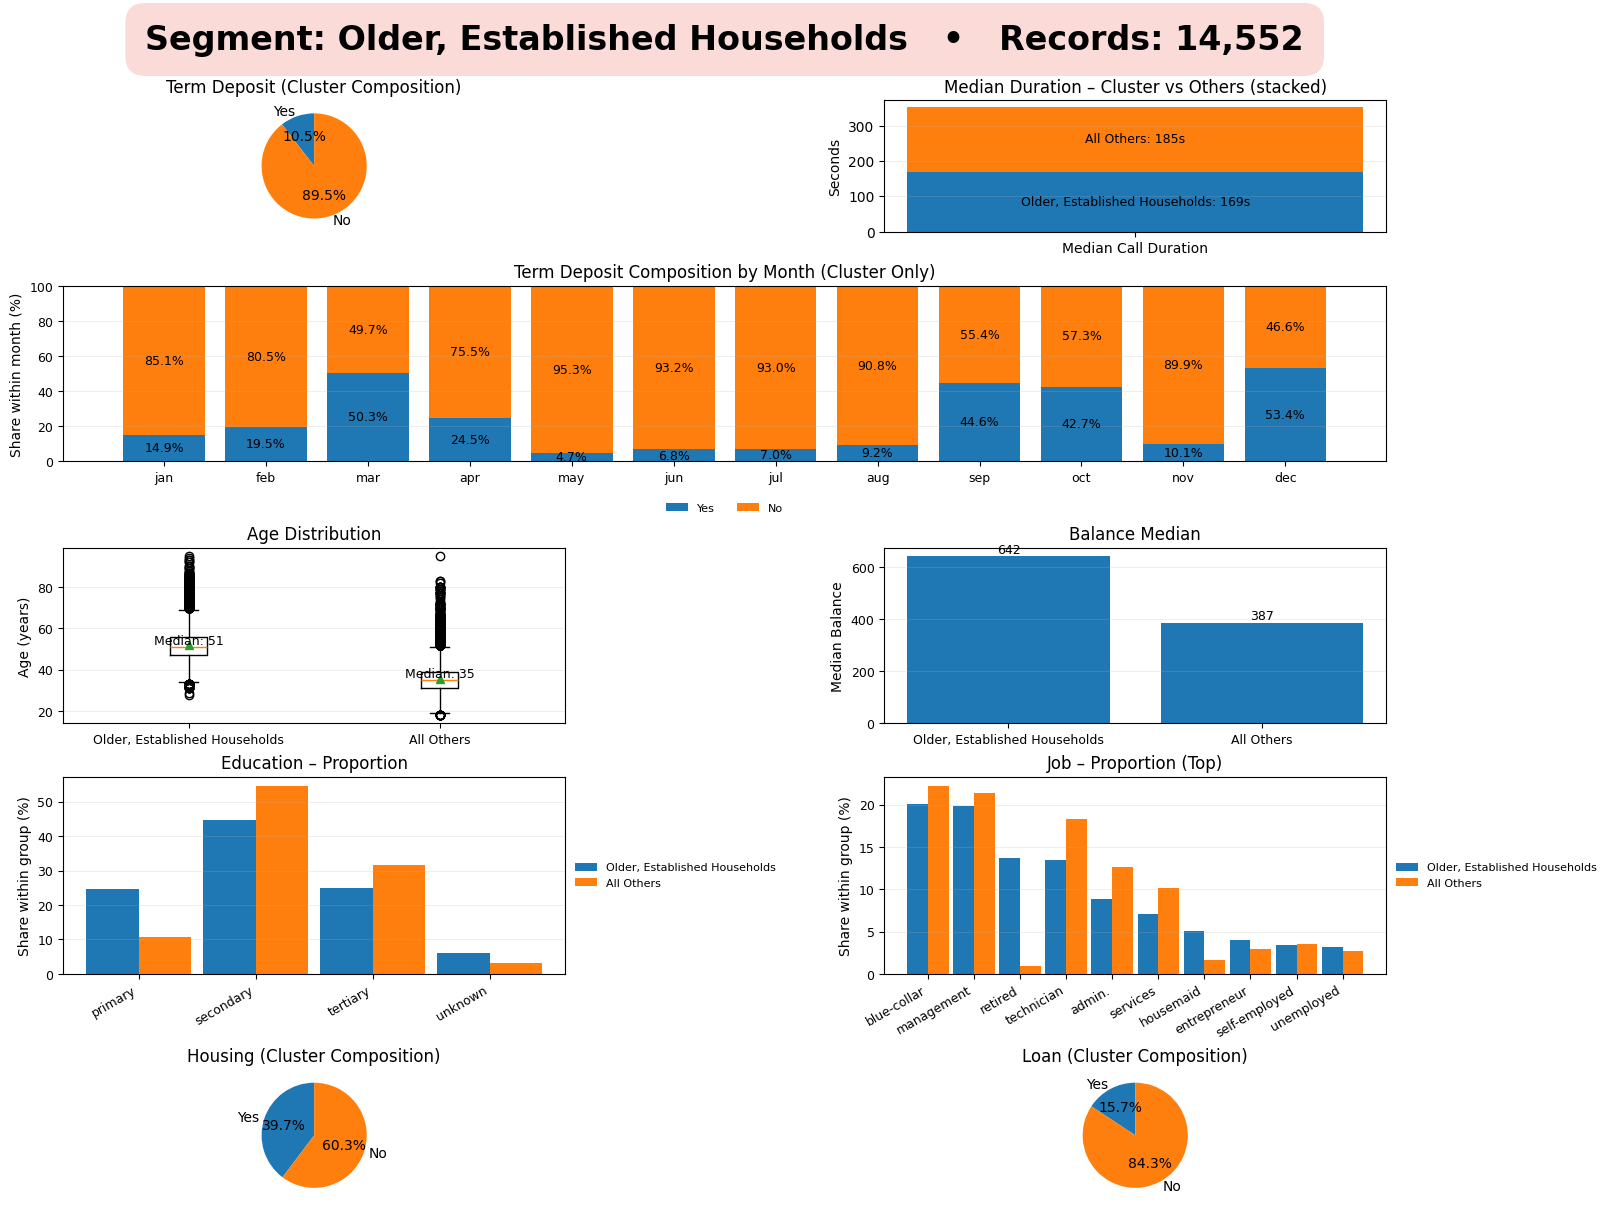

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Optional

# ===================== CONFIG =====================
_MONTH_ORDER = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

# ===================== UTILITIES =====================
def _month_cat(series: pd.Series) -> pd.Categorical:
    s = series.astype(str).str.lower()
    return pd.Categorical(s, categories=_MONTH_ORDER, ordered=True)

def _poutcome_known_rate(s: pd.Series) -> float:
    """Share of poutcome that is not 'unknown'."""
    if len(s) == 0:
        return 0.0
    return 1.0 - (s.astype(str).eq('unknown').mean())

# ===================== DYNAMIC LABELING =====================
def assign_dynamic_cluster_labels(df4: pd.DataFrame) -> dict:
    """
    Assign human labels to numeric cluster IDs based on profile metrics.
      - 'Previously Targeted, Mixed Response Clients' -> highest pdays (tie: most known poutcome)
      - 'Over-Contacted, Low Engagement Group'       -> highest campaign
      - 'Older, Established Households'              -> (remaining) highest age (tie: highest balance)
      - 'Young Working Professionals with Debt Exposure' -> remaining cluster
    """
    g = df4.groupby('cluster', dropna=False)
    stats = pd.DataFrame({
        'n': g.size(),
        'age_mean': g['age'].mean(),
        'balance_mean': g['balance'].mean(),
        'campaign_mean': g['campaign'].mean(),
        'pdays_mean': g['pdays'].mean(),
        'poutcome_known_rate': g['poutcome'].apply(_poutcome_known_rate)
    })

    # 1) Previously targeted
    c_prev = (stats[['pdays_mean','poutcome_known_rate']]
              .sort_values(['pdays_mean','poutcome_known_rate'], ascending=False)
              .index[0])

    # 2) Over-contacted
    remaining = stats.drop(index=c_prev)
    c_over = remaining['campaign_mean'].idxmax()

    # 3) Older, established
    remaining = remaining.drop(index=c_over)
    c_old = (remaining[['age_mean','balance_mean']]
             .sort_values(['age_mean','balance_mean'], ascending=False)
             .index[0])

    # 4) Young working (leftover)
    remaining = remaining.drop(index=c_old)
    c_young = remaining.index[0] if len(remaining) == 1 else stats['age_mean'].idxmin()

    label_map = {
        c_old:   "Older, Established Households",
        c_young: "Young Working Professionals with Debt Exposure",
        c_prev:  "Previously Targeted, Mixed Response Clients",
        c_over:  "Over-Contacted, Low Engagement Group",
    }
    if df4['cluster'].nunique() != len(label_map):
        raise ValueError("Label mapping mismatch with cluster count.")
    return label_map

def ensure_dynamic_labels(df4: pd.DataFrame) -> pd.DataFrame:
    """Attach/refresh df4['cluster_label'] based on the latest cluster assignments."""
    label_map = assign_dynamic_cluster_labels(df4)
    out = df4.copy()
    out['cluster_label'] = out['cluster'].map(label_map)
    return out

def ensure_y_binary(df4: pd.DataFrame) -> pd.DataFrame:
    """Create df4['y_bin'] from 'y' ('yes'/'no')."""
    if 'y_bin' not in df4.columns:
        df4 = df4.copy()
        df4['y_bin'] = df4['y'].map({'yes': 1, 'no': 0})
    return df4

def print_labeling_summary(df4: pd.DataFrame) -> None:
    label_map = assign_dynamic_cluster_labels(df4)
    print("Dynamic label mapping (cluster_id -> label):")
    for cid, lab in label_map.items():
        print(f"  {cid}: {lab}")
    tmp = df4.copy()
    tmp['cluster_label'] = tmp['cluster'].map(label_map)
    print("\nCounts by label:")
    print(tmp['cluster_label'].value_counts())

# ===================== SUMMARIES =====================
def _cluster_id_from_label(df4: pd.DataFrame, label: str) -> int:
    d = (df4[['cluster','cluster_label']]
         .drop_duplicates()
         .set_index('cluster_label')['cluster']
         .to_dict())
    return d[label]

def _summaries_for_cluster(df4: pd.DataFrame, cluster_id: int,
                           job_top_n: int = 10, min_prop: float = 0.01) -> dict:
    lbl = df4.loc[df4['cluster']==cluster_id, 'cluster_label'].iloc[0]
    in_grp  = df4[df4['cluster']==cluster_id].copy()
    out_grp = df4[df4['cluster']!=cluster_id].copy()

    # Age arrays
    age_in  = in_grp['age'].dropna()
    age_out = out_grp['age'].dropna()

    # Balance medians
    bal_med_in  = in_grp['balance'].median()
    bal_med_out = out_grp['balance'].median()

    # Duration medians
    dur_med_in  = in_grp['duration'].median()
    dur_med_out = out_grp['duration'].median()

    # Education proportions
    edu_in  = in_grp['education'].value_counts(normalize=True, dropna=False)
    edu_out = out_grp['education'].value_counts(normalize=True, dropna=False)
    edu_all = sorted(set(edu_in.index).union(edu_out.index), key=lambda x: str(x))
    edu_in, edu_out = edu_in.reindex(edu_all, fill_value=0), edu_out.reindex(edu_all, fill_value=0)
    keep = (edu_in >= min_prop) | (edu_out >= min_prop)
    edu_in, edu_out = edu_in[keep], edu_out[keep]

    # Job proportions (top N by cluster share)
    job_in  = in_grp['job'].value_counts(normalize=True, dropna=False)
    job_out = out_grp['job'].value_counts(normalize=True, dropna=False)
    job_all = sorted(set(job_in.index).union(job_out.index), key=lambda x: str(x))
    job_in, job_out = job_in.reindex(job_all, fill_value=0), job_out.reindex(job_all, fill_value=0)
    if len(job_in) > job_top_n:
        top_jobs = job_in.sort_values(ascending=False).head(job_top_n).index
        job_in, job_out = job_in.loc[top_jobs], job_out.loc[top_jobs]

    # Term deposit composition (counts) – cluster only
    yes_in_cnt  = int(in_grp['y_bin'].sum())
    no_in_cnt   = int(len(in_grp) - yes_in_cnt)

    # Month Yes/No composition (100% stacked) – cluster only
    tmp = in_grp.copy()
    tmp['month_cat'] = _month_cat(tmp['month'])
    month_yes = tmp[tmp['y']=='yes'].groupby('month_cat').size()
    month_no  = tmp[tmp['y']=='no'].groupby('month_cat').size()
    idx = pd.Index(_MONTH_ORDER, dtype='object')  # consistent order
    month_yes = month_yes.reindex(idx, fill_value=0)
    month_no  = month_no.reindex(idx,  fill_value=0)
    month_tot = month_yes + month_no
    with np.errstate(divide='ignore', invalid='ignore'):
        month_yes_pct = (month_yes / month_tot.replace(0, np.nan) * 100).fillna(0)
        month_no_pct  = (month_no  / month_tot.replace(0, np.nan) * 100).fillna(0)

    # Housing & Loan composition (cluster-only pies)
    housing_yes = float(in_grp['housing'].eq('yes').mean())
    housing_no  = 1.0 - housing_yes
    loan_yes    = float(in_grp['loan'].eq('yes').mean())
    loan_no     = 1.0 - loan_yes

    return dict(
        label=lbl,
        age_in=age_in, age_out=age_out,
        bal_med_in=bal_med_in, bal_med_out=bal_med_out,
        dur_med_in=dur_med_in, dur_med_out=dur_med_out,
        edu_in=edu_in, edu_out=edu_out,
        job_in=job_in, job_out=job_out,
        td_counts=[yes_in_cnt, no_in_cnt],
        month_yes_pct=month_yes_pct, month_no_pct=month_no_pct,
        housing_counts=[housing_yes, housing_no],
        loan_counts=[loan_yes, loan_no]
    )

# ===================== HELPERS (LABELS) =====================
def _bar_percent_labels(ax):
    """Add percentage labels centered in each bar container (0-100 scale)."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
        except Exception:
            pass

def _bar_value_labels(ax, fmt='%.0f'):
    """Add numeric labels centered in each bar."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt=fmt, label_type='center', fontsize=9)
        except Exception:
            pass

# ===================== RENDERER =====================
def render_cluster_slide(df4: pd.DataFrame, cluster_label: str,
                         save_path: Optional[str] = None) -> None:
    """
    Wide slide:
      - Header banner
      - KPI row: Term deposit pie (cluster-only) + Median Duration (cluster vs others, stacked VERTICAL)
      - Month: 100% stacked bars of y (Yes/No) by month for the selected cluster ONLY (full width, with % labels)
      - Age box (vs others; taller; median labels) + Balance median (vs others; value labels)
      - Education + Job proportions (taller; % labels; legends outside)
      - Housing pie + Loan pie (cluster-only)
    """
    # Ensure latest labels + y_bin
    df4 = ensure_dynamic_labels(df4)
    df4 = ensure_y_binary(df4)

    cid = _cluster_id_from_label(df4, cluster_label)
    S = _summaries_for_cluster(df4, cid)

    # 6 rows; give more height to Age/Edu/Job rows
    fig = plt.figure(figsize=(16, 12), constrained_layout=True)
    gs = GridSpec(6, 2, figure=fig,
                  height_ratios=[0.55, 1.2, 1.6, 1.6, 1.8, 1.2])

    # ---- Header banner ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    total_n = int((df4['cluster_label']==cluster_label).sum())
    ax_title.text(
        0.5, 0.5,
        f"Segment: {S['label']}   •   Records: {total_n:,}",
        ha="center", va="center",
        fontsize=24, fontweight="bold",
        bbox=dict(facecolor="#FADBD8", edgecolor="none", boxstyle="round,pad=0.6")
    )

    # ---- Row 2: KPI charts ----
    # Left: Term deposit pie (cluster-only)
    ax_td = fig.add_subplot(gs[1, 0])
    ax_td.pie(S['td_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_td.set_title("Term Deposit (Cluster Composition)")

    # Right: Median Duration (stacked VERTICAL) with inline labels
    ax_dur = fig.add_subplot(gs[1, 1])
    # one vertical bar with two stacked segments
    seg1 = S['dur_med_in']
    seg2 = S['dur_med_out']
    ax_dur.bar([0], [seg1], label=S['label'])
    ax_dur.bar([0], [seg2], bottom=[seg1], label="All Others")
    # inline labels
    if seg1 > 0:
        ax_dur.text(0, seg1/2, f"{S['label']}: {seg1:.0f}s", ha="center", va="center", fontsize=9)
    if seg2 > 0:
        ax_dur.text(0, seg1 + seg2/2, f"All Others: {seg2:.0f}s", ha="center", va="center", fontsize=9)
    ax_dur.set_xticks([0]); ax_dur.set_xticklabels(["Median Call Duration"])
    ax_dur.set_ylabel("Seconds")
    ax_dur.set_title("Median Duration – Cluster vs Others (stacked)")
    ax_dur.grid(True, axis='y', linewidth=0.5, alpha=0.3)

    # ---- Row 3: Month y-composition (cluster-only, full width) ----
    ax_month = fig.add_subplot(gs[2, :])
    months = list(S['month_yes_pct'].index)
    yes_vals = S['month_yes_pct'].values
    no_vals  = S['month_no_pct'].values
    x = np.arange(len(months))
    b1 = ax_month.bar(x, yes_vals, label='Yes')
    b2 = ax_month.bar(x, no_vals, bottom=yes_vals, label='No')
    ax_month.set_xticks(x)
    ax_month.set_xticklabels(months)
    ax_month.set_ylim(0, 100)
    ax_month.set_ylabel("Share within month (%)")
    ax_month.set_title("Term Deposit Composition by Month (Cluster Only)")
    ax_month.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8, frameon=False)
    ax_month.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    _bar_percent_labels(ax_month)

    # ---- Row 4: Age + Balance ----
    ax_age = fig.add_subplot(gs[3, 0])
    ax_age.boxplot([S['age_in'], S['age_out']],
                   labels=[S['label'], "All Others"], vert=True, showmeans=True)
    ax_age.set_title("Age Distribution")
    ax_age.set_ylabel("Age (years)")
    ax_age.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    # annotate medians
    age_med_in  = np.median(S['age_in'])
    age_med_out = np.median(S['age_out'])
    ax_age.text(1, age_med_in,  f"Median: {age_med_in:.0f}", ha='center', va='bottom', fontsize=9)
    ax_age.text(2, age_med_out, f"Median: {age_med_out:.0f}", ha='center', va='bottom', fontsize=9)

    ax_bal = fig.add_subplot(gs[3, 1])
    xs = [S['label'], "All Others"]
    ys = [S['bal_med_in'], S['bal_med_out']]
    bars = ax_bal.bar(xs, ys)
    ax_bal.set_title("Balance Median")
    ax_bal.set_ylabel("Median Balance")
    ax_bal.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    for bar, v in zip(bars, ys):
        ax_bal.text(bar.get_x() + bar.get_width()/2, v, f"{v:.0f}", ha='center', va='bottom', fontsize=9)



    # ---- Row 5: Education + Job (taller, no labels, fixed legends) ----
    ax_edu = fig.add_subplot(gs[4, 0])
    xe = np.arange(len(S['edu_in'])); w = 0.45
    b_in  = ax_edu.bar(xe - w/2, S['edu_in'].values * 100, width=w, label=S['label'])
    b_out = ax_edu.bar(xe + w/2, S['edu_out'].values * 100, width=w, label="All Others")
    ax_edu.set_xticks(xe)
    ax_edu.set_xticklabels([str(c) for c in S['edu_in'].index], rotation=30, ha='right')
    ax_edu.set_title("Education – Proportion")
    ax_edu.set_ylabel("Share within group (%)")
    ax_edu.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    ax_edu.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

    ax_job = fig.add_subplot(gs[4, 1])
    xj = np.arange(len(S['job_in']))
    bj_in  = ax_job.bar(xj - w/2, S['job_in'].values * 100, width=w, label=S['label'])
    bj_out = ax_job.bar(xj + w/2, S['job_out'].values * 100, width=w, label="All Others")
    ax_job.set_xticks(xj)
    ax_job.set_xticklabels([str(c) for c in S['job_in'].index], rotation=30, ha='right')
    ax_job.set_title("Job – Proportion (Top)")
    ax_job.set_ylabel("Share within group (%)")
    ax_job.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    ax_job.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

    
    # ---- Row 6: Housing + Loan pies (cluster-only) ----
    ax_housing = fig.add_subplot(gs[5, 0])
    ax_housing.pie(S['housing_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_housing.set_title("Housing (Cluster Composition)")

    ax_loan = fig.add_subplot(gs[5, 1])
    ax_loan.pie(S['loan_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_loan.set_title("Loan (Cluster Composition)")

    # Consistent tick font sizes
    for ax in [ax_age, ax_bal, ax_edu, ax_job, ax_month]:
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(9)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

# ===================== CONVENIENCE =====================
def render_cluster_slide_by_id(df4: pd.DataFrame, cluster_id: int, **kwargs) -> None:
    """Render by numeric cluster id; resolves the current dynamic label."""
    tmp = ensure_dynamic_labels(df4)
    label = tmp.loc[tmp['cluster']==cluster_id, 'cluster_label'].iloc[0]
    render_cluster_slide(tmp, cluster_label=label, **kwargs)

# ===================== EXAMPLES =====================
print_labeling_summary(df4)
render_cluster_slide(df4, cluster_label="Older, Established Households")

#render_cluster_slide_by_id(df4, 1, save_path="slide_cluster1.png")


Dynamic label mapping (cluster_id -> label):
  0: Older, Established Households
  1: Young Working Professionals with Debt Exposure
  2: Previously Targeted, Mixed Response Clients
  3: Over-Contacted, Low Engagement Group

Counts by label:
cluster_label
Young Working Professionals with Debt Exposure    21871
Older, Established Households                     14552
Previously Targeted, Mixed Response Clients        7002
Over-Contacted, Low Engagement Group               1786
Name: count, dtype: int64


/tmp/ipykernel_580920/1254770560.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_yes = tmp[tmp['y']=='yes'].groupby('month_cat').size()
/tmp/ipykernel_580920/1254770560.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_no  = tmp[tmp['y']=='no'].groupby('month_cat').size()
/tmp/ipykernel_580920/1254770560.py:267: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_age.boxplot([S['age_in'], S['age_out']],


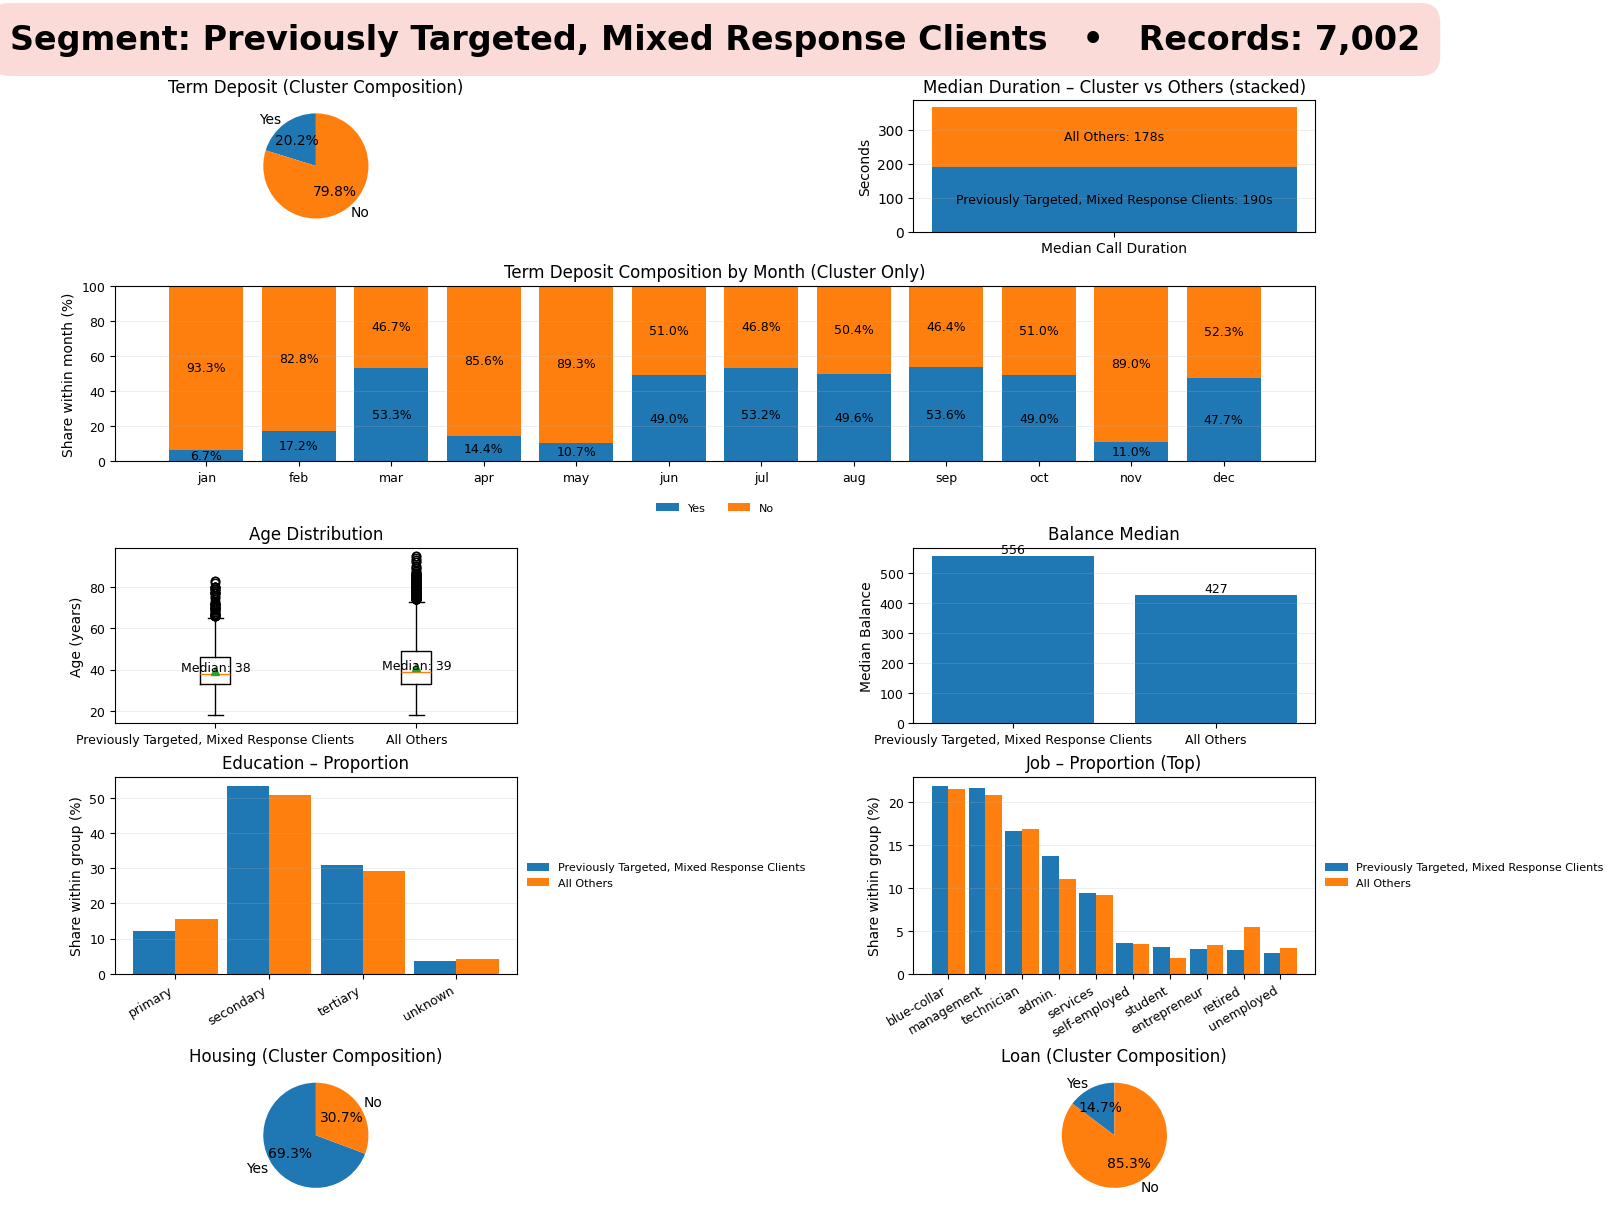

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Optional

# ===================== CONFIG =====================
_MONTH_ORDER = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

# ===================== UTILITIES =====================
def _month_cat(series: pd.Series) -> pd.Categorical:
    s = series.astype(str).str.lower()
    return pd.Categorical(s, categories=_MONTH_ORDER, ordered=True)

def _poutcome_known_rate(s: pd.Series) -> float:
    """Share of poutcome that is not 'unknown'."""
    if len(s) == 0:
        return 0.0
    return 1.0 - (s.astype(str).eq('unknown').mean())

# ===================== DYNAMIC LABELING =====================
def assign_dynamic_cluster_labels(df4: pd.DataFrame) -> dict:
    """
    Assign human labels to numeric cluster IDs based on profile metrics.
      - 'Previously Targeted, Mixed Response Clients' -> highest pdays (tie: most known poutcome)
      - 'Over-Contacted, Low Engagement Group'       -> highest campaign
      - 'Older, Established Households'              -> (remaining) highest age (tie: highest balance)
      - 'Young Working Professionals with Debt Exposure' -> remaining cluster
    """
    g = df4.groupby('cluster', dropna=False)
    stats = pd.DataFrame({
        'n': g.size(),
        'age_mean': g['age'].mean(),
        'balance_mean': g['balance'].mean(),
        'campaign_mean': g['campaign'].mean(),
        'pdays_mean': g['pdays'].mean(),
        'poutcome_known_rate': g['poutcome'].apply(_poutcome_known_rate)
    })

    # 1) Previously targeted
    c_prev = (stats[['pdays_mean','poutcome_known_rate']]
              .sort_values(['pdays_mean','poutcome_known_rate'], ascending=False)
              .index[0])

    # 2) Over-contacted
    remaining = stats.drop(index=c_prev)
    c_over = remaining['campaign_mean'].idxmax()

    # 3) Older, established
    remaining = remaining.drop(index=c_over)
    c_old = (remaining[['age_mean','balance_mean']]
             .sort_values(['age_mean','balance_mean'], ascending=False)
             .index[0])

    # 4) Young working (leftover)
    remaining = remaining.drop(index=c_old)
    c_young = remaining.index[0] if len(remaining) == 1 else stats['age_mean'].idxmin()

    label_map = {
        c_old:   "Older, Established Households",
        c_young: "Young Working Professionals with Debt Exposure",
        c_prev:  "Previously Targeted, Mixed Response Clients",
        c_over:  "Over-Contacted, Low Engagement Group",
    }
    if df4['cluster'].nunique() != len(label_map):
        raise ValueError("Label mapping mismatch with cluster count.")
    return label_map

def ensure_dynamic_labels(df4: pd.DataFrame) -> pd.DataFrame:
    """Attach/refresh df4['cluster_label'] based on the latest cluster assignments."""
    label_map = assign_dynamic_cluster_labels(df4)
    out = df4.copy()
    out['cluster_label'] = out['cluster'].map(label_map)
    return out

def ensure_y_binary(df4: pd.DataFrame) -> pd.DataFrame:
    """Create df4['y_bin'] from 'y' ('yes'/'no')."""
    if 'y_bin' not in df4.columns:
        df4 = df4.copy()
        df4['y_bin'] = df4['y'].map({'yes': 1, 'no': 0})
    return df4

def print_labeling_summary(df4: pd.DataFrame) -> None:
    label_map = assign_dynamic_cluster_labels(df4)
    print("Dynamic label mapping (cluster_id -> label):")
    for cid, lab in label_map.items():
        print(f"  {cid}: {lab}")
    tmp = df4.copy()
    tmp['cluster_label'] = tmp['cluster'].map(label_map)
    print("\nCounts by label:")
    print(tmp['cluster_label'].value_counts())

# ===================== SUMMARIES =====================
def _cluster_id_from_label(df4: pd.DataFrame, label: str) -> int:
    d = (df4[['cluster','cluster_label']]
         .drop_duplicates()
         .set_index('cluster_label')['cluster']
         .to_dict())
    return d[label]

def _summaries_for_cluster(df4: pd.DataFrame, cluster_id: int,
                           job_top_n: int = 10, min_prop: float = 0.01) -> dict:
    lbl = df4.loc[df4['cluster']==cluster_id, 'cluster_label'].iloc[0]
    in_grp  = df4[df4['cluster']==cluster_id].copy()
    out_grp = df4[df4['cluster']!=cluster_id].copy()

    # Age arrays
    age_in  = in_grp['age'].dropna()
    age_out = out_grp['age'].dropna()

    # Balance medians
    bal_med_in  = in_grp['balance'].median()
    bal_med_out = out_grp['balance'].median()

    # Duration medians
    dur_med_in  = in_grp['duration'].median()
    dur_med_out = out_grp['duration'].median()

    # Education proportions
    edu_in  = in_grp['education'].value_counts(normalize=True, dropna=False)
    edu_out = out_grp['education'].value_counts(normalize=True, dropna=False)
    edu_all = sorted(set(edu_in.index).union(edu_out.index), key=lambda x: str(x))
    edu_in, edu_out = edu_in.reindex(edu_all, fill_value=0), edu_out.reindex(edu_all, fill_value=0)
    keep = (edu_in >= min_prop) | (edu_out >= min_prop)
    edu_in, edu_out = edu_in[keep], edu_out[keep]

    # Job proportions (top N by cluster share)
    job_in  = in_grp['job'].value_counts(normalize=True, dropna=False)
    job_out = out_grp['job'].value_counts(normalize=True, dropna=False)
    job_all = sorted(set(job_in.index).union(job_out.index), key=lambda x: str(x))
    job_in, job_out = job_in.reindex(job_all, fill_value=0), job_out.reindex(job_all, fill_value=0)
    if len(job_in) > job_top_n:
        top_jobs = job_in.sort_values(ascending=False).head(job_top_n).index
        job_in, job_out = job_in.loc[top_jobs], job_out.loc[top_jobs]

    # Term deposit composition (counts) – cluster only
    yes_in_cnt  = int(in_grp['y_bin'].sum())
    no_in_cnt   = int(len(in_grp) - yes_in_cnt)

    # Month Yes/No composition (100% stacked) – cluster only
    tmp = in_grp.copy()
    tmp['month_cat'] = _month_cat(tmp['month'])
    month_yes = tmp[tmp['y']=='yes'].groupby('month_cat').size()
    month_no  = tmp[tmp['y']=='no'].groupby('month_cat').size()
    idx = pd.Index(_MONTH_ORDER, dtype='object')  # consistent order
    month_yes = month_yes.reindex(idx, fill_value=0)
    month_no  = month_no.reindex(idx,  fill_value=0)
    month_tot = month_yes + month_no
    with np.errstate(divide='ignore', invalid='ignore'):
        month_yes_pct = (month_yes / month_tot.replace(0, np.nan) * 100).fillna(0)
        month_no_pct  = (month_no  / month_tot.replace(0, np.nan) * 100).fillna(0)

    # Housing & Loan composition (cluster-only pies)
    housing_yes = float(in_grp['housing'].eq('yes').mean())
    housing_no  = 1.0 - housing_yes
    loan_yes    = float(in_grp['loan'].eq('yes').mean())
    loan_no     = 1.0 - loan_yes

    return dict(
        label=lbl,
        age_in=age_in, age_out=age_out,
        bal_med_in=bal_med_in, bal_med_out=bal_med_out,
        dur_med_in=dur_med_in, dur_med_out=dur_med_out,
        edu_in=edu_in, edu_out=edu_out,
        job_in=job_in, job_out=job_out,
        td_counts=[yes_in_cnt, no_in_cnt],
        month_yes_pct=month_yes_pct, month_no_pct=month_no_pct,
        housing_counts=[housing_yes, housing_no],
        loan_counts=[loan_yes, loan_no]
    )

# ===================== HELPERS (LABELS) =====================
def _bar_percent_labels(ax):
    """Add percentage labels centered in each bar container (0-100 scale)."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
        except Exception:
            pass

def _bar_value_labels(ax, fmt='%.0f'):
    """Add numeric labels centered in each bar."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt=fmt, label_type='center', fontsize=9)
        except Exception:
            pass

# ===================== RENDERER =====================
def render_cluster_slide(df4: pd.DataFrame, cluster_label: str,
                         save_path: Optional[str] = None) -> None:
    """
    Wide slide:
      - Header banner
      - KPI row: Term deposit pie (cluster-only) + Median Duration (cluster vs others, stacked VERTICAL)
      - Month: 100% stacked bars of y (Yes/No) by month for the selected cluster ONLY (full width, with % labels)
      - Age box (vs others; taller; median labels) + Balance median (vs others; value labels)
      - Education + Job proportions (taller; % labels; legends outside)
      - Housing pie + Loan pie (cluster-only)
    """
    # Ensure latest labels + y_bin
    df4 = ensure_dynamic_labels(df4)
    df4 = ensure_y_binary(df4)

    cid = _cluster_id_from_label(df4, cluster_label)
    S = _summaries_for_cluster(df4, cid)

    # 6 rows; give more height to Age/Edu/Job rows
    fig = plt.figure(figsize=(16, 12), constrained_layout=True)
    gs = GridSpec(6, 2, figure=fig,
                  height_ratios=[0.55, 1.2, 1.6, 1.6, 1.8, 1.2])

    # ---- Header banner ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    total_n = int((df4['cluster_label']==cluster_label).sum())
    ax_title.text(
        0.5, 0.5,
        f"Segment: {S['label']}   •   Records: {total_n:,}",
        ha="center", va="center",
        fontsize=24, fontweight="bold",
        bbox=dict(facecolor="#FADBD8", edgecolor="none", boxstyle="round,pad=0.6")
    )

    # ---- Row 2: KPI charts ----
    # Left: Term deposit pie (cluster-only)
    ax_td = fig.add_subplot(gs[1, 0])
    ax_td.pie(S['td_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_td.set_title("Term Deposit (Cluster Composition)")

    # Right: Median Duration (stacked VERTICAL) with inline labels
    ax_dur = fig.add_subplot(gs[1, 1])
    # one vertical bar with two stacked segments
    seg1 = S['dur_med_in']
    seg2 = S['dur_med_out']
    ax_dur.bar([0], [seg1], label=S['label'])
    ax_dur.bar([0], [seg2], bottom=[seg1], label="All Others")
    # inline labels
    if seg1 > 0:
        ax_dur.text(0, seg1/2, f"{S['label']}: {seg1:.0f}s", ha="center", va="center", fontsize=9)
    if seg2 > 0:
        ax_dur.text(0, seg1 + seg2/2, f"All Others: {seg2:.0f}s", ha="center", va="center", fontsize=9)
    ax_dur.set_xticks([0]); ax_dur.set_xticklabels(["Median Call Duration"])
    ax_dur.set_ylabel("Seconds")
    ax_dur.set_title("Median Duration – Cluster vs Others (stacked)")
    ax_dur.grid(True, axis='y', linewidth=0.5, alpha=0.3)

    # ---- Row 3: Month y-composition (cluster-only, full width) ----
    ax_month = fig.add_subplot(gs[2, :])
    months = list(S['month_yes_pct'].index)
    yes_vals = S['month_yes_pct'].values
    no_vals  = S['month_no_pct'].values
    x = np.arange(len(months))
    b1 = ax_month.bar(x, yes_vals, label='Yes')
    b2 = ax_month.bar(x, no_vals, bottom=yes_vals, label='No')
    ax_month.set_xticks(x)
    ax_month.set_xticklabels(months)
    ax_month.set_ylim(0, 100)
    ax_month.set_ylabel("Share within month (%)")
    ax_month.set_title("Term Deposit Composition by Month (Cluster Only)")
    ax_month.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8, frameon=False)
    ax_month.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    _bar_percent_labels(ax_month)

    # ---- Row 4: Age + Balance ----
    ax_age = fig.add_subplot(gs[3, 0])
    ax_age.boxplot([S['age_in'], S['age_out']],
                   labels=[S['label'], "All Others"], vert=True, showmeans=True)
    ax_age.set_title("Age Distribution")
    ax_age.set_ylabel("Age (years)")
    ax_age.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    # annotate medians
    age_med_in  = np.median(S['age_in'])
    age_med_out = np.median(S['age_out'])
    ax_age.text(1, age_med_in,  f"Median: {age_med_in:.0f}", ha='center', va='bottom', fontsize=9)
    ax_age.text(2, age_med_out, f"Median: {age_med_out:.0f}", ha='center', va='bottom', fontsize=9)

    ax_bal = fig.add_subplot(gs[3, 1])
    xs = [S['label'], "All Others"]
    ys = [S['bal_med_in'], S['bal_med_out']]
    bars = ax_bal.bar(xs, ys)
    ax_bal.set_title("Balance Median")
    ax_bal.set_ylabel("Median Balance")
    ax_bal.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    for bar, v in zip(bars, ys):
        ax_bal.text(bar.get_x() + bar.get_width()/2, v, f"{v:.0f}", ha='center', va='bottom', fontsize=9)



    # ---- Row 5: Education + Job (taller, no labels, fixed legends) ----
    ax_edu = fig.add_subplot(gs[4, 0])
    xe = np.arange(len(S['edu_in'])); w = 0.45
    b_in  = ax_edu.bar(xe - w/2, S['edu_in'].values * 100, width=w, label=S['label'])
    b_out = ax_edu.bar(xe + w/2, S['edu_out'].values * 100, width=w, label="All Others")
    ax_edu.set_xticks(xe)
    ax_edu.set_xticklabels([str(c) for c in S['edu_in'].index], rotation=30, ha='right')
    ax_edu.set_title("Education – Proportion")
    ax_edu.set_ylabel("Share within group (%)")
    ax_edu.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    ax_edu.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

    ax_job = fig.add_subplot(gs[4, 1])
    xj = np.arange(len(S['job_in']))
    bj_in  = ax_job.bar(xj - w/2, S['job_in'].values * 100, width=w, label=S['label'])
    bj_out = ax_job.bar(xj + w/2, S['job_out'].values * 100, width=w, label="All Others")
    ax_job.set_xticks(xj)
    ax_job.set_xticklabels([str(c) for c in S['job_in'].index], rotation=30, ha='right')
    ax_job.set_title("Job – Proportion (Top)")
    ax_job.set_ylabel("Share within group (%)")
    ax_job.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    ax_job.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

    
    # ---- Row 6: Housing + Loan pies (cluster-only) ----
    ax_housing = fig.add_subplot(gs[5, 0])
    ax_housing.pie(S['housing_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_housing.set_title("Housing (Cluster Composition)")

    ax_loan = fig.add_subplot(gs[5, 1])
    ax_loan.pie(S['loan_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_loan.set_title("Loan (Cluster Composition)")

    # Consistent tick font sizes
    for ax in [ax_age, ax_bal, ax_edu, ax_job, ax_month]:
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(9)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

# ===================== CONVENIENCE =====================
def render_cluster_slide_by_id(df4: pd.DataFrame, cluster_id: int, **kwargs) -> None:
    """Render by numeric cluster id; resolves the current dynamic label."""
    tmp = ensure_dynamic_labels(df4)
    label = tmp.loc[tmp['cluster']==cluster_id, 'cluster_label'].iloc[0]
    render_cluster_slide(tmp, cluster_label=label, **kwargs)

# ===================== EXAMPLES =====================
print_labeling_summary(df4)
render_cluster_slide(df4, cluster_label="Previously Targeted, Mixed Response Clients")


#render_cluster_slide_by_id(df4, 1, save_path="slide_cluster1.png")


Dynamic label mapping (cluster_id -> label):
  0: Older, Established Households
  1: Young Working Professionals with Debt Exposure
  2: Previously Targeted, Mixed Response Clients
  3: Over-Contacted, Low Engagement Group

Counts by label:
cluster_label
Young Working Professionals with Debt Exposure    21871
Older, Established Households                     14552
Previously Targeted, Mixed Response Clients        7002
Over-Contacted, Low Engagement Group               1786
Name: count, dtype: int64


/tmp/ipykernel_580920/294562713.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_yes = tmp[tmp['y']=='yes'].groupby('month_cat').size()
/tmp/ipykernel_580920/294562713.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_no  = tmp[tmp['y']=='no'].groupby('month_cat').size()
/tmp/ipykernel_580920/294562713.py:267: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_age.boxplot([S['age_in'], S['age_out']],


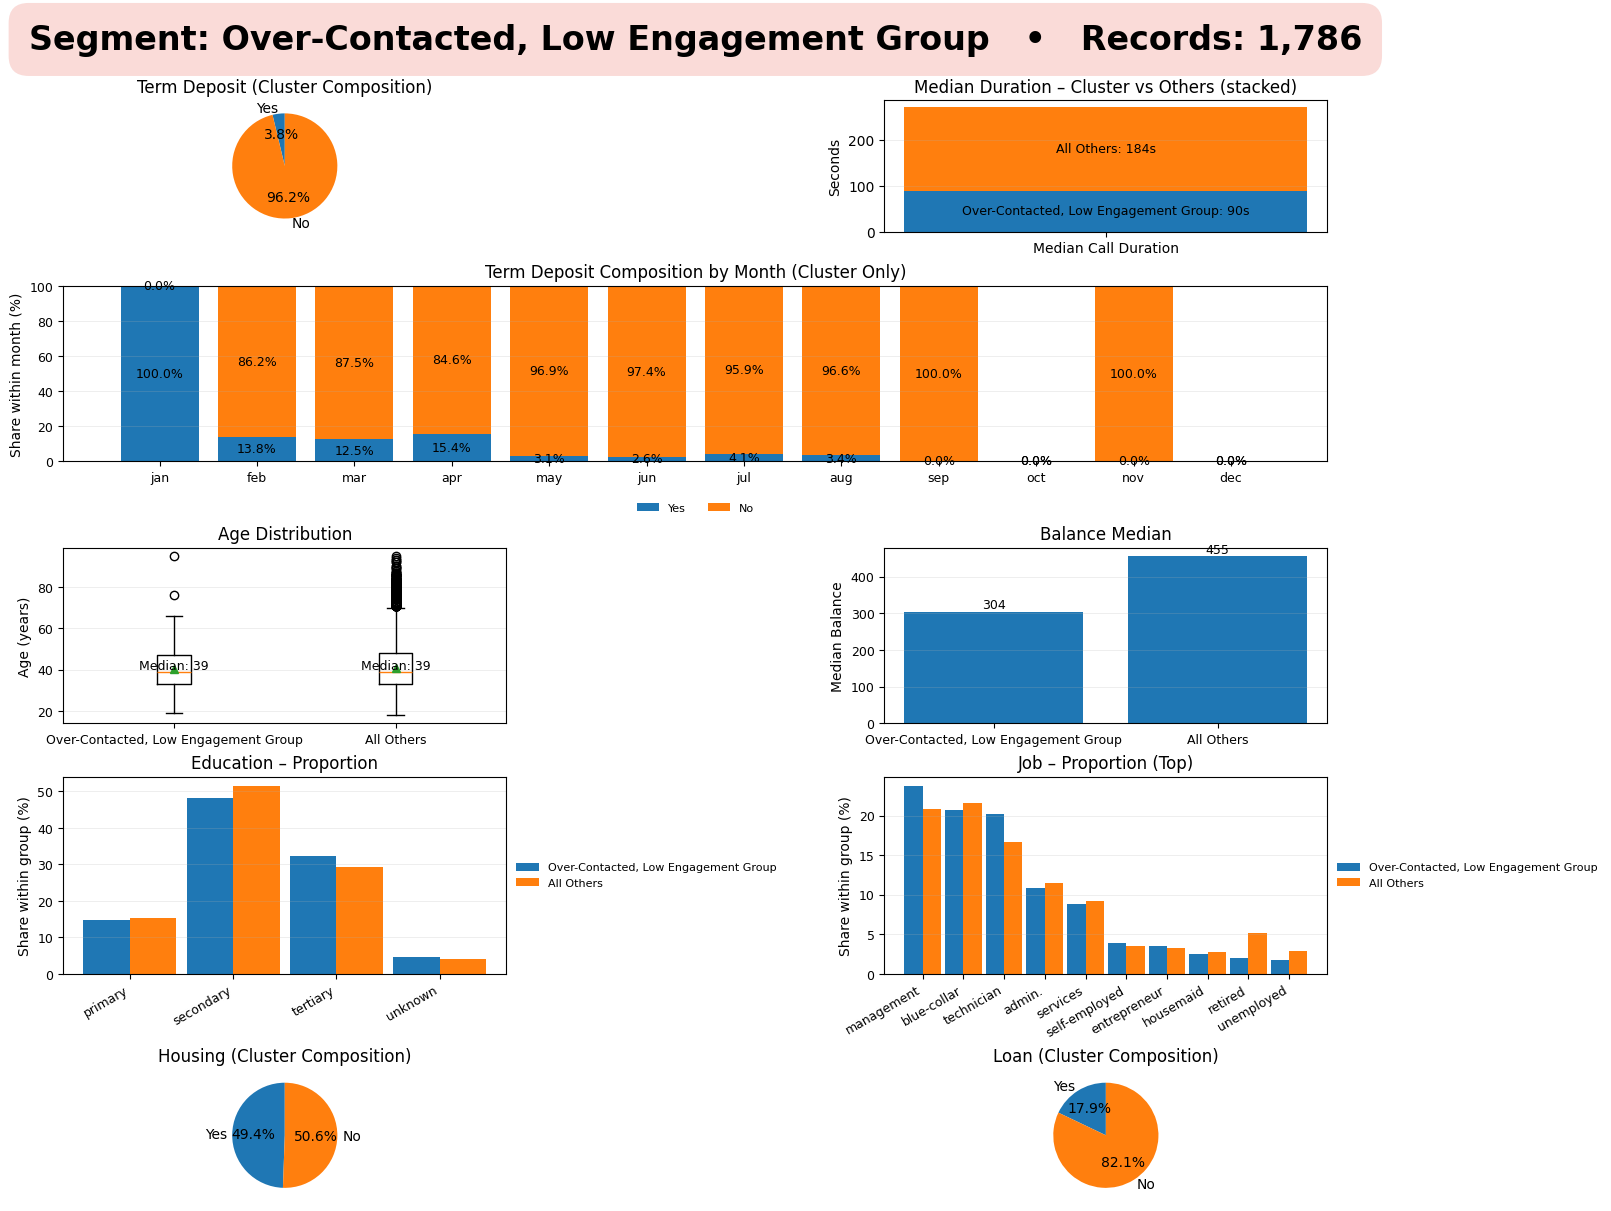

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Optional

# ===================== CONFIG =====================
_MONTH_ORDER = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

# ===================== UTILITIES =====================
def _month_cat(series: pd.Series) -> pd.Categorical:
    s = series.astype(str).str.lower()
    return pd.Categorical(s, categories=_MONTH_ORDER, ordered=True)

def _poutcome_known_rate(s: pd.Series) -> float:
    """Share of poutcome that is not 'unknown'."""
    if len(s) == 0:
        return 0.0
    return 1.0 - (s.astype(str).eq('unknown').mean())

# ===================== DYNAMIC LABELING =====================
def assign_dynamic_cluster_labels(df4: pd.DataFrame) -> dict:
    """
    Assign human labels to numeric cluster IDs based on profile metrics.
      - 'Previously Targeted, Mixed Response Clients' -> highest pdays (tie: most known poutcome)
      - 'Over-Contacted, Low Engagement Group'       -> highest campaign
      - 'Older, Established Households'              -> (remaining) highest age (tie: highest balance)
      - 'Young Working Professionals with Debt Exposure' -> remaining cluster
    """
    g = df4.groupby('cluster', dropna=False)
    stats = pd.DataFrame({
        'n': g.size(),
        'age_mean': g['age'].mean(),
        'balance_mean': g['balance'].mean(),
        'campaign_mean': g['campaign'].mean(),
        'pdays_mean': g['pdays'].mean(),
        'poutcome_known_rate': g['poutcome'].apply(_poutcome_known_rate)
    })

    # 1) Previously targeted
    c_prev = (stats[['pdays_mean','poutcome_known_rate']]
              .sort_values(['pdays_mean','poutcome_known_rate'], ascending=False)
              .index[0])

    # 2) Over-contacted
    remaining = stats.drop(index=c_prev)
    c_over = remaining['campaign_mean'].idxmax()

    # 3) Older, established
    remaining = remaining.drop(index=c_over)
    c_old = (remaining[['age_mean','balance_mean']]
             .sort_values(['age_mean','balance_mean'], ascending=False)
             .index[0])

    # 4) Young working (leftover)
    remaining = remaining.drop(index=c_old)
    c_young = remaining.index[0] if len(remaining) == 1 else stats['age_mean'].idxmin()

    label_map = {
        c_old:   "Older, Established Households",
        c_young: "Young Working Professionals with Debt Exposure",
        c_prev:  "Previously Targeted, Mixed Response Clients",
        c_over:  "Over-Contacted, Low Engagement Group",
    }
    if df4['cluster'].nunique() != len(label_map):
        raise ValueError("Label mapping mismatch with cluster count.")
    return label_map

def ensure_dynamic_labels(df4: pd.DataFrame) -> pd.DataFrame:
    """Attach/refresh df4['cluster_label'] based on the latest cluster assignments."""
    label_map = assign_dynamic_cluster_labels(df4)
    out = df4.copy()
    out['cluster_label'] = out['cluster'].map(label_map)
    return out

def ensure_y_binary(df4: pd.DataFrame) -> pd.DataFrame:
    """Create df4['y_bin'] from 'y' ('yes'/'no')."""
    if 'y_bin' not in df4.columns:
        df4 = df4.copy()
        df4['y_bin'] = df4['y'].map({'yes': 1, 'no': 0})
    return df4

def print_labeling_summary(df4: pd.DataFrame) -> None:
    label_map = assign_dynamic_cluster_labels(df4)
    print("Dynamic label mapping (cluster_id -> label):")
    for cid, lab in label_map.items():
        print(f"  {cid}: {lab}")
    tmp = df4.copy()
    tmp['cluster_label'] = tmp['cluster'].map(label_map)
    print("\nCounts by label:")
    print(tmp['cluster_label'].value_counts())

# ===================== SUMMARIES =====================
def _cluster_id_from_label(df4: pd.DataFrame, label: str) -> int:
    d = (df4[['cluster','cluster_label']]
         .drop_duplicates()
         .set_index('cluster_label')['cluster']
         .to_dict())
    return d[label]

def _summaries_for_cluster(df4: pd.DataFrame, cluster_id: int,
                           job_top_n: int = 10, min_prop: float = 0.01) -> dict:
    lbl = df4.loc[df4['cluster']==cluster_id, 'cluster_label'].iloc[0]
    in_grp  = df4[df4['cluster']==cluster_id].copy()
    out_grp = df4[df4['cluster']!=cluster_id].copy()

    # Age arrays
    age_in  = in_grp['age'].dropna()
    age_out = out_grp['age'].dropna()

    # Balance medians
    bal_med_in  = in_grp['balance'].median()
    bal_med_out = out_grp['balance'].median()

    # Duration medians
    dur_med_in  = in_grp['duration'].median()
    dur_med_out = out_grp['duration'].median()

    # Education proportions
    edu_in  = in_grp['education'].value_counts(normalize=True, dropna=False)
    edu_out = out_grp['education'].value_counts(normalize=True, dropna=False)
    edu_all = sorted(set(edu_in.index).union(edu_out.index), key=lambda x: str(x))
    edu_in, edu_out = edu_in.reindex(edu_all, fill_value=0), edu_out.reindex(edu_all, fill_value=0)
    keep = (edu_in >= min_prop) | (edu_out >= min_prop)
    edu_in, edu_out = edu_in[keep], edu_out[keep]

    # Job proportions (top N by cluster share)
    job_in  = in_grp['job'].value_counts(normalize=True, dropna=False)
    job_out = out_grp['job'].value_counts(normalize=True, dropna=False)
    job_all = sorted(set(job_in.index).union(job_out.index), key=lambda x: str(x))
    job_in, job_out = job_in.reindex(job_all, fill_value=0), job_out.reindex(job_all, fill_value=0)
    if len(job_in) > job_top_n:
        top_jobs = job_in.sort_values(ascending=False).head(job_top_n).index
        job_in, job_out = job_in.loc[top_jobs], job_out.loc[top_jobs]

    # Term deposit composition (counts) – cluster only
    yes_in_cnt  = int(in_grp['y_bin'].sum())
    no_in_cnt   = int(len(in_grp) - yes_in_cnt)

    # Month Yes/No composition (100% stacked) – cluster only
    tmp = in_grp.copy()
    tmp['month_cat'] = _month_cat(tmp['month'])
    month_yes = tmp[tmp['y']=='yes'].groupby('month_cat').size()
    month_no  = tmp[tmp['y']=='no'].groupby('month_cat').size()
    idx = pd.Index(_MONTH_ORDER, dtype='object')  # consistent order
    month_yes = month_yes.reindex(idx, fill_value=0)
    month_no  = month_no.reindex(idx,  fill_value=0)
    month_tot = month_yes + month_no
    with np.errstate(divide='ignore', invalid='ignore'):
        month_yes_pct = (month_yes / month_tot.replace(0, np.nan) * 100).fillna(0)
        month_no_pct  = (month_no  / month_tot.replace(0, np.nan) * 100).fillna(0)

    # Housing & Loan composition (cluster-only pies)
    housing_yes = float(in_grp['housing'].eq('yes').mean())
    housing_no  = 1.0 - housing_yes
    loan_yes    = float(in_grp['loan'].eq('yes').mean())
    loan_no     = 1.0 - loan_yes

    return dict(
        label=lbl,
        age_in=age_in, age_out=age_out,
        bal_med_in=bal_med_in, bal_med_out=bal_med_out,
        dur_med_in=dur_med_in, dur_med_out=dur_med_out,
        edu_in=edu_in, edu_out=edu_out,
        job_in=job_in, job_out=job_out,
        td_counts=[yes_in_cnt, no_in_cnt],
        month_yes_pct=month_yes_pct, month_no_pct=month_no_pct,
        housing_counts=[housing_yes, housing_no],
        loan_counts=[loan_yes, loan_no]
    )

# ===================== HELPERS (LABELS) =====================
def _bar_percent_labels(ax):
    """Add percentage labels centered in each bar container (0-100 scale)."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
        except Exception:
            pass

def _bar_value_labels(ax, fmt='%.0f'):
    """Add numeric labels centered in each bar."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt=fmt, label_type='center', fontsize=9)
        except Exception:
            pass

# ===================== RENDERER =====================
def render_cluster_slide(df4: pd.DataFrame, cluster_label: str,
                         save_path: Optional[str] = None) -> None:
    """
    Wide slide:
      - Header banner
      - KPI row: Term deposit pie (cluster-only) + Median Duration (cluster vs others, stacked VERTICAL)
      - Month: 100% stacked bars of y (Yes/No) by month for the selected cluster ONLY (full width, with % labels)
      - Age box (vs others; taller; median labels) + Balance median (vs others; value labels)
      - Education + Job proportions (taller; % labels; legends outside)
      - Housing pie + Loan pie (cluster-only)
    """
    # Ensure latest labels + y_bin
    df4 = ensure_dynamic_labels(df4)
    df4 = ensure_y_binary(df4)

    cid = _cluster_id_from_label(df4, cluster_label)
    S = _summaries_for_cluster(df4, cid)

    # 6 rows; give more height to Age/Edu/Job rows
    fig = plt.figure(figsize=(16, 12), constrained_layout=True)
    gs = GridSpec(6, 2, figure=fig,
                  height_ratios=[0.55, 1.2, 1.6, 1.6, 1.8, 1.2])

    # ---- Header banner ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    total_n = int((df4['cluster_label']==cluster_label).sum())
    ax_title.text(
        0.5, 0.5,
        f"Segment: {S['label']}   •   Records: {total_n:,}",
        ha="center", va="center",
        fontsize=24, fontweight="bold",
        bbox=dict(facecolor="#FADBD8", edgecolor="none", boxstyle="round,pad=0.6")
    )

    # ---- Row 2: KPI charts ----
    # Left: Term deposit pie (cluster-only)
    ax_td = fig.add_subplot(gs[1, 0])
    ax_td.pie(S['td_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_td.set_title("Term Deposit (Cluster Composition)")

    # Right: Median Duration (stacked VERTICAL) with inline labels
    ax_dur = fig.add_subplot(gs[1, 1])
    # one vertical bar with two stacked segments
    seg1 = S['dur_med_in']
    seg2 = S['dur_med_out']
    ax_dur.bar([0], [seg1], label=S['label'])
    ax_dur.bar([0], [seg2], bottom=[seg1], label="All Others")
    # inline labels
    if seg1 > 0:
        ax_dur.text(0, seg1/2, f"{S['label']}: {seg1:.0f}s", ha="center", va="center", fontsize=9)
    if seg2 > 0:
        ax_dur.text(0, seg1 + seg2/2, f"All Others: {seg2:.0f}s", ha="center", va="center", fontsize=9)
    ax_dur.set_xticks([0]); ax_dur.set_xticklabels(["Median Call Duration"])
    ax_dur.set_ylabel("Seconds")
    ax_dur.set_title("Median Duration – Cluster vs Others (stacked)")
    ax_dur.grid(True, axis='y', linewidth=0.5, alpha=0.3)

    # ---- Row 3: Month y-composition (cluster-only, full width) ----
    ax_month = fig.add_subplot(gs[2, :])
    months = list(S['month_yes_pct'].index)
    yes_vals = S['month_yes_pct'].values
    no_vals  = S['month_no_pct'].values
    x = np.arange(len(months))
    b1 = ax_month.bar(x, yes_vals, label='Yes')
    b2 = ax_month.bar(x, no_vals, bottom=yes_vals, label='No')
    ax_month.set_xticks(x)
    ax_month.set_xticklabels(months)
    ax_month.set_ylim(0, 100)
    ax_month.set_ylabel("Share within month (%)")
    ax_month.set_title("Term Deposit Composition by Month (Cluster Only)")
    ax_month.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8, frameon=False)
    ax_month.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    _bar_percent_labels(ax_month)

    # ---- Row 4: Age + Balance ----
    ax_age = fig.add_subplot(gs[3, 0])
    ax_age.boxplot([S['age_in'], S['age_out']],
                   labels=[S['label'], "All Others"], vert=True, showmeans=True)
    ax_age.set_title("Age Distribution")
    ax_age.set_ylabel("Age (years)")
    ax_age.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    # annotate medians
    age_med_in  = np.median(S['age_in'])
    age_med_out = np.median(S['age_out'])
    ax_age.text(1, age_med_in,  f"Median: {age_med_in:.0f}", ha='center', va='bottom', fontsize=9)
    ax_age.text(2, age_med_out, f"Median: {age_med_out:.0f}", ha='center', va='bottom', fontsize=9)

    ax_bal = fig.add_subplot(gs[3, 1])
    xs = [S['label'], "All Others"]
    ys = [S['bal_med_in'], S['bal_med_out']]
    bars = ax_bal.bar(xs, ys)
    ax_bal.set_title("Balance Median")
    ax_bal.set_ylabel("Median Balance")
    ax_bal.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    for bar, v in zip(bars, ys):
        ax_bal.text(bar.get_x() + bar.get_width()/2, v, f"{v:.0f}", ha='center', va='bottom', fontsize=9)



    # ---- Row 5: Education + Job (taller, no labels, fixed legends) ----
    ax_edu = fig.add_subplot(gs[4, 0])
    xe = np.arange(len(S['edu_in'])); w = 0.45
    b_in  = ax_edu.bar(xe - w/2, S['edu_in'].values * 100, width=w, label=S['label'])
    b_out = ax_edu.bar(xe + w/2, S['edu_out'].values * 100, width=w, label="All Others")
    ax_edu.set_xticks(xe)
    ax_edu.set_xticklabels([str(c) for c in S['edu_in'].index], rotation=30, ha='right')
    ax_edu.set_title("Education – Proportion")
    ax_edu.set_ylabel("Share within group (%)")
    ax_edu.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    ax_edu.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

    ax_job = fig.add_subplot(gs[4, 1])
    xj = np.arange(len(S['job_in']))
    bj_in  = ax_job.bar(xj - w/2, S['job_in'].values * 100, width=w, label=S['label'])
    bj_out = ax_job.bar(xj + w/2, S['job_out'].values * 100, width=w, label="All Others")
    ax_job.set_xticks(xj)
    ax_job.set_xticklabels([str(c) for c in S['job_in'].index], rotation=30, ha='right')
    ax_job.set_title("Job – Proportion (Top)")
    ax_job.set_ylabel("Share within group (%)")
    ax_job.grid(True, axis='y', linewidth=0.5, alpha=0.3)
    ax_job.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

    
    # ---- Row 6: Housing + Loan pies (cluster-only) ----
    ax_housing = fig.add_subplot(gs[5, 0])
    ax_housing.pie(S['housing_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_housing.set_title("Housing (Cluster Composition)")

    ax_loan = fig.add_subplot(gs[5, 1])
    ax_loan.pie(S['loan_counts'], labels=["Yes", "No"], autopct='%1.1f%%', startangle=90)
    ax_loan.set_title("Loan (Cluster Composition)")

    # Consistent tick font sizes
    for ax in [ax_age, ax_bal, ax_edu, ax_job, ax_month]:
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(9)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

# ===================== CONVENIENCE =====================
def render_cluster_slide_by_id(df4: pd.DataFrame, cluster_id: int, **kwargs) -> None:
    """Render by numeric cluster id; resolves the current dynamic label."""
    tmp = ensure_dynamic_labels(df4)
    label = tmp.loc[tmp['cluster']==cluster_id, 'cluster_label'].iloc[0]
    render_cluster_slide(tmp, cluster_label=label, **kwargs)

# ===================== EXAMPLES =====================
print_labeling_summary(df4)
render_cluster_slide(df4, cluster_label="Over-Contacted, Low Engagement Group")



#render_cluster_slide_by_id(df4, 1, save_path="slide_cluster1.png")
